<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/06_Notion_Review_TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notion Google Play Review TF-IDF**


## **⚙️ Process Description**

| Step | Task | Tool | Description |
|------|------|------|-------------|
| 1 | Load dataset | pandas | Load raw dataset containing review text and sentiment labels |
| 2 | Data preprocessing | pandas, re | Clean text by removing noise, duplicates, and standardizing text format |
| 3 | Train-test split | scikit-learn | Split dataset into training and testing sets using stratified sampling |
| 4 | Bag of Words feature extraction | scikit-learn | Convert text into numerical features using word frequency representation |
| 5 | TF-IDF transformation | scikit-learn | Reweight BoW features using term importance (TF-IDF scoring) |
| 6 | Word embedding generation | TensorFlow Hub | Convert text into dense semantic vectors using USE embeddings |
| 7 | Feature combination | numpy | Concatenate TF-IDF and USE features into a hybrid representation |
| 8 | Model initialization | scikit-learn, xgboost | Define classifiers (SVM, Logistic Regression, Naive Bayes, XGBoost, Random Forest) |
| 9 | Model training | scikit-learn, xgboost | Train classifiers using TF-IDF, USE, and combined features |
| 10 | Model evaluation | scikit-learn | Evaluate models using Accuracy, Precision, Recall, and F1-score |
| 11 | Performance comparison | pandas | Compare all models across different feature representations |
| 12 | Result visualization | matplotlib | Visualize model performance using bar charts |
| 13 | Final model selection | pandas | Rank models and select the best performing model based on F1-score |

### **Install dan Import Library**

In [1]:
pip install -U nltk tensorflow_hub xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.8 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


In [2]:
import pandas as pd
import numpy as np
import torch
import nltk
from collections import Counter
from timeit import default_timer as timer

import tensorflow as tf
import tensorflow_hub as hub

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import vstack

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

### **Check GPU Availability**

In [4]:
is_cuda = torch.cuda.is_available()
device  = torch.device('cuda') if is_cuda else torch.device('cpu')
print(f'Device : {device}')
print(f'GPU    : {is_cuda}')
if is_cuda:
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')

# Check GPU Availability
tf_gpus = tf.config.list_physical_devices('GPU')
print(f'TF Check GPU Availability: {len(tf_gpus) > 0} ({len(tf_gpus)} device)')


Device : cpu
GPU    : False
TF Check GPU Availability: False (0 device)


### **Load Dataset**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from IPython.display import display

df = pd.read_csv('/content/drive/MyDrive/Tugas Individu/Dataset/review_notion_sentiment.csv')

print(f'Total data: {df.shape[0]:,} rows, {df.shape[1]} columns')
print()


count = df['sentiment_label'].value_counts()
prop  = df['sentiment_label'].value_counts(normalize=True).round(4)
summary_df = pd.DataFrame({
    'Count': count,
    'Proportion': prop
})

summary_df = summary_df.reset_index()
summary_df.columns = ['Sentiment', 'Count', 'Proportion']
print('Initial Sentiment Distribution (Full Dataset):')
display(summary_df)

Total data: 20,758 rows, 11 columns

Initial Sentiment Distribution (Full Dataset):


,Sentiment,Count,Proportion
0,positive,11483,0.5532
1,neutral,6797,0.3274
2,negative,2478,0.1194


### **Setup & Data Loading**

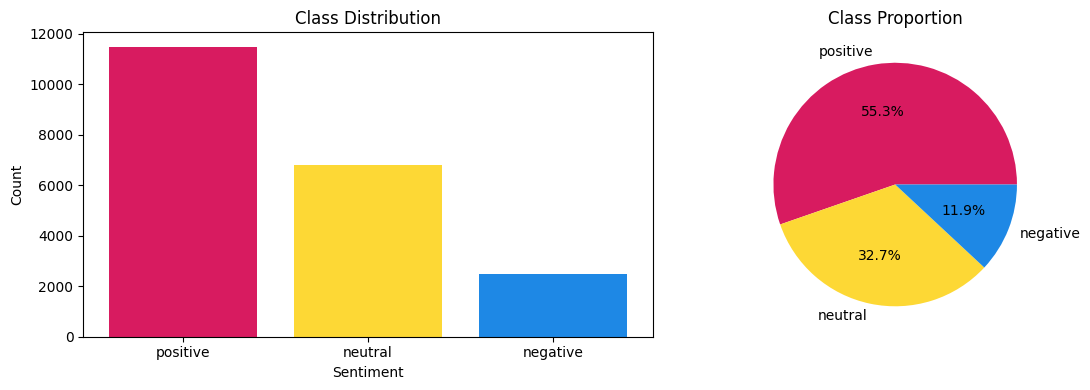

Positive:Neutral = 1.7:1


In [7]:
# Class distribution before subsampling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sentiment_counts = df['sentiment_label'].value_counts()
colors = ['#D81B60', '#FDD835', '#1E88E5']

# Bar chart
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=colors, autopct='%1.1f%%')

axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

print(f'Positive:Neutral = {sentiment_counts["positive"]/sentiment_counts["neutral"]:.1f}:1')

In [8]:
TOTAL_SAMPLE = 60_000
MIN_PER_CLASS = 8_000  # ensure minority class is represented

# Filter valid data
df_valid = df[
    df['final_text'].notna() &
    (df['final_text'].astype(str).str.strip() != '')
].copy()

print(f'Valid data: {len(df_valid):,} out of {len(df):,}')

# Use correct column name
class_counts = df_valid['sentiment_label'].value_counts()
total_valid = len(df_valid)

# Compute quotas
quotas = {}
for cls in class_counts.index:
    proportional = int(TOTAL_SAMPLE * (class_counts[cls] / total_valid))
    quotas[cls] = max(proportional, MIN_PER_CLASS)

# Adjust if exceeding total sample size
current_total = sum(quotas.values())
if current_total > TOTAL_SAMPLE:
    biggest = max(quotas, key=quotas.get)
    quotas[biggest] -= (current_total - TOTAL_SAMPLE)

# Build table output
summary_df = pd.DataFrame({
    'Class': class_counts.index,
    'Available': class_counts.values,
    'Quota': [quotas[c] for c in class_counts.index]
})

summary_df['Percentage'] = (summary_df['Quota'] / summary_df['Available'] * 100).round(2)

display(summary_df)

Valid data: 20,758 out of 20,758


,Class,Available,Quota,Percentage
0,positive,11483,32354,281.76
1,neutral,6797,19646,289.04
2,negative,2478,8000,322.84


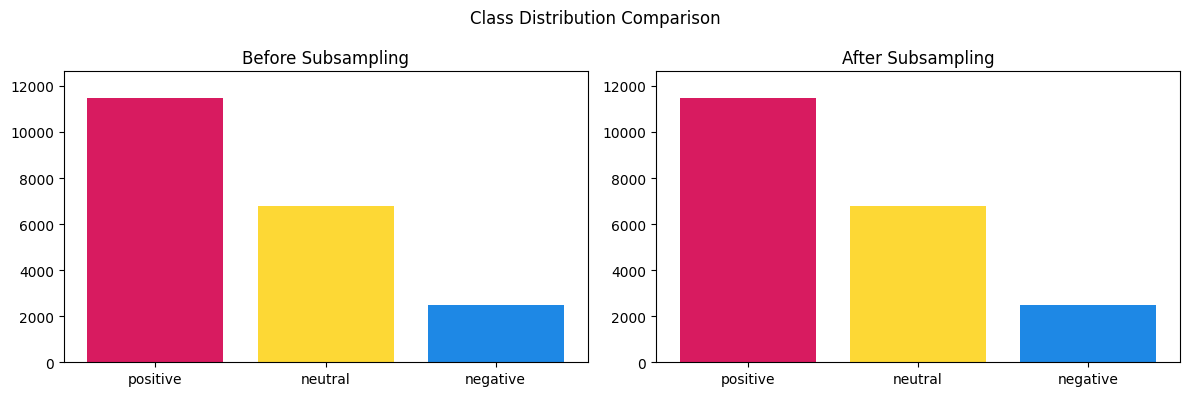

In [9]:
# Compare distribution before and after subsampling

df_sampled_list = []

for cls, q in quotas.items():
    class_df = df_valid[df_valid['sentiment_label'] == cls]
    df_sampled_list.append(class_df.sample(n=min(q, len(class_df)), random_state=42))

df_sampled = pd.concat(df_sampled_list).sample(frac=1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = df['sentiment_label'].value_counts()
after  = df_sampled['sentiment_label'].value_counts()

max_y = max(before.max(), after.max()) * 1.1

for ax, data, title in zip(
    axes,
    [before, after],
    ['Before Subsampling', 'After Subsampling']
):
    ax.bar(data.index, data.values, color=colors)
    ax.set_title(title)
    ax.set_ylim(0, max_y)

plt.suptitle('Class Distribution Comparison')
plt.tight_layout()
plt.show()

### **Label Encoding & Train-Test Split**

In [10]:
label_encode = LabelEncoder()
Y_encoded = label_encode.fit_transform(df_sampled['sentiment_label'])

CLASS_NAMES = list(label_encode.classes_)
print(f'Label Mapping : {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
print('Catatan       : 0 = negative, 1 = neutral, 2 = positive')

Label Mapping : ['negative', 'neutral', 'positive'] -> [0 1 2]
Catatan       : 0 = negative, 1 = neutral, 2 = positive


In [11]:
# Prepare features and labels
x_data = df_sampled['final_text'].astype(str)
y_data = Y_encoded

# Train-test split with stratification
xtrain, xtest, ytrain, ytest = train_test_split(
    x_data,
    y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

print(f'Training set: {len(xtrain):,} samples')
print(f'Test set: {len(xtest):,} samples')
print()

# Function to create distribution table
def create_dist_table(y_split, split_name):
    counts = pd.Series(y_split).value_counts().sort_index()

    df_table = pd.DataFrame({
        'Class': [CLASS_NAMES[i] for i in counts.index],
        'Count': counts.values,
        'Percentage': (counts.values / len(y_split) * 100).round(2)
    })

    df_table['Split'] = split_name
    return df_table

# Create tables
train_table = create_dist_table(ytrain, 'Train')
test_table  = create_dist_table(ytest, 'Test')

# Combine tables
result_table = pd.concat([train_table, test_table], ignore_index=True)

# Display result
from IPython.display import display
display(result_table)

Training set: 16,606 samples
Test set: 4,152 samples



,Class,Count,Percentage,Split
0,negative,1982,11.94,Train
1,neutral,5438,32.75,Train
2,positive,9186,55.32,Train
3,negative,496,11.95,Test
4,neutral,1359,32.73,Test
5,positive,2297,55.32,Test


### **Vocabulary Analysis of Training Data**

In [12]:
word_counts = Counter(' '.join(str(t) for t in xtrain).split())
print(f'Total kata unik: {len(word_counts):,}')
print()
print('50 kata paling sering:')
for word, count in word_counts.most_common(50):
    print(f'  {word}: {count:,}')

Total kata unik: 4,068

50 kata paling sering:
  app: 11,157
  use: 4,799
  notion: 3,574
  note: 2,878
  work: 2,195
  love: 2,069
  great: 2,054
  like: 1,789
  best: 1,750
  good: 1,736
  take: 1,560
  page: 1,515
  realli: 1,489
  time: 1,432
  make: 1,424
  mobil: 1,355
  one: 1,316
  android: 1,300
  featur: 1,283
  slow: 1,227
  need: 1,207
  pleas: 1,119
  cant: 1,086
  open: 1,082
  get: 1,039
  version: 1,033
  would: 1,015
  thing: 996
  help: 983
  organ: 978
  phone: 958
  keep: 933
  much: 932
  even: 910
  load: 883
  product: 877
  im: 863
  amaz: 859
  fix: 845
  doesnt: 829
  life: 824
  tri: 822
  want: 820
  desktop: 802
  updat: 785
  also: 756
  text: 748
  offlin: 741
  lot: 729
  add: 715


### **Classifier Initialization and Evaluation Function**

In [13]:
# Compute sample weights for XGBoost (computed once, reused across all sections)
sample_weights = compute_sample_weight(class_weight='balanced', y=ytrain)

# Create weight table
weight_table = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Sample Weight': [
        sample_weights[ytrain == i][0] for i in range(len(CLASS_NAMES))
    ]
})

from IPython.display import display

print('Class sample weights (XGBoost):')
display(weight_table)

Class sample weights (XGBoost):


,Class,Sample Weight
0,negative,2.792802
1,neutral,1.017899
2,positive,0.602584


In [14]:
def init_classifiers():
    svm = LinearSVC(max_iter=2000, random_state=42, class_weight='balanced')
    lr  = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
    nb  = MultinomialNB()
    xgb = XGBClassifier(
        objective='multi:softmax', eval_metric='mlogloss',
        num_class=len(CLASS_NAMES), random_state=42,
        n_estimators=100, learning_rate=0.1,
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    rfc = RandomForestClassifier(
        n_estimators=100, max_depth=15, max_features='sqrt',
        min_samples_leaf=2, n_jobs=-1, random_state=42,
        class_weight='balanced'
    )
    return svm, lr, nb, xgb, rfc

In [15]:
def evaluate_model(model, xtest_data, ytest_labels, target_names=CLASS_NAMES):
    y_pred    = model.predict(xtest_data)
    accuracy  = accuracy_score(ytest_labels, y_pred)
    precision = precision_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    report    = classification_report(ytest_labels, y_pred, target_names=target_names, zero_division=0)
    cm        = confusion_matrix(ytest_labels, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

batch_size = 1000
print('Setup completed. Ready to start training.')

Setup completed. Ready to start training.


### **A. Feature Extraction**

#### **Bag of Words (CountVectorizer)**

In [16]:
print('STEP 1: Bag of Words (CountVectorizer)')

bow_vec = CountVectorizer(max_features=5000)
bow_vec.fit(xtrain.tolist())

xtrain_bow = vstack([
    bow_vec.transform(xtrain.tolist()[i:i+batch_size])
    for i in range(0, len(xtrain), batch_size)
])

xtest_bow = vstack([
    bow_vec.transform(xtest.tolist()[i:i+batch_size])
    for i in range(0, len(xtest), batch_size)
])

vocab = bow_vec.get_feature_names_out()

bow_summary = pd.DataFrame([{
    'Train Shape': xtrain_bow.shape,
    'Test Shape': xtest_bow.shape,
    'Vocabulary': len(vocab),
    'Non-zero': xtrain_bow.nnz,
    'Sparsity (%)': round((1 - xtrain_bow.nnz / (xtrain_bow.shape[0] * xtrain_bow.shape[1])) * 100, 2)
}])

bow_summary

STEP 1: Bag of Words (CountVectorizer)


,Train Shape,Test Shape,Vocabulary,Non-zero,Sparsity (%)
0,"(16606, 4037)","(4152, 4037)",4037,187261,99.72


#### **TF-IDF**

In [17]:
print('STEP 2: TF-IDF (TfidfTransformer)')

tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(xtrain_bow)

xtrain_tfidf = tfidf_transformer.transform(xtrain_bow)
xtest_tfidf  = tfidf_transformer.transform(xtest_bow)

tfidf_summary = pd.DataFrame([{
    'Train Shape': xtrain_tfidf.shape,
    'Test Shape': xtest_tfidf.shape,
    'Matrix Type': type(xtrain_tfidf).__name__,
}])

tfidf_summary

STEP 2: TF-IDF (TfidfTransformer)


,Train Shape,Test Shape,Matrix Type
0,"(16606, 4037)","(4152, 4037)",csr_matrix


In [18]:
# Compare BoW vs TF-IDF for a sample review

bow_row   = np.asarray(xtrain_bow[0].todense()).flatten()
tfidf_row = np.asarray(xtrain_tfidf[0].todense()).flatten()

nonzero = np.where(bow_row > 0)[0]
nonzero_sorted = nonzero[bow_row[nonzero].argsort()[::-1]]

print('BoW vs TF-IDF Comparison (first training sample)')
print(f'Review: "{xtrain.iloc[0][:80]}..."')
print()

print(f'{"Word":20s} {"BoW":>10s} {"TF-IDF":>12s}')
print('-' * 45)

for idx in nonzero_sorted[:10]:
    print(f'{vocab[idx]:20s} {int(bow_row[idx]):>10} {tfidf_row[idx]:>12.4f}')

print()
print('Note:')
print('- Common words → high BoW, low TF-IDF')
print('- Rare words   → lower BoW, higher TF-IDF')

BoW vs TF-IDF Comparison (first training sample)
Review: "awesom function..."

Word                        BoW       TF-IDF
---------------------------------------------
function                      1       0.6795
awesom                        1       0.7337

Note:
- Common words → high BoW, low TF-IDF
- Rare words   → lower BoW, higher TF-IDF


In [19]:
# Training 5 classifier
svm_c, lr_c, nb_c, xgb_c, rfc_c = init_classifiers()
print('Training classifier TF-IDF...')
print()

start = timer(); svm_tfidf = svm_c.fit(xtrain_tfidf, ytrain)
print(f'  Linear SVM       : {timer()-start:.2f}s')

start = timer(); lr_tfidf = lr_c.fit(xtrain_tfidf, ytrain)
print(f'  Logistic Reg     : {timer()-start:.2f}s')

start = timer(); nb_tfidf = nb_c.fit(xtrain_tfidf, ytrain)
print(f'  Naive Bayes      : {timer()-start:.2f}s')

start = timer(); xgb_tfidf = xgb_c.fit(xtrain_tfidf, ytrain, sample_weight=sample_weights)
print(f'  XGBoost          : {timer()-start:.2f}s')

start = timer(); rfc_tfidf = rfc_c.fit(xtrain_tfidf, ytrain)
print(f'  Random Forest    : {timer()-start:.2f}s')
print()
print('Training TF-IDF Completed.')

Training classifier TF-IDF...

  Linear SVM       : 0.14s
  Logistic Reg     : 3.19s
  Naive Bayes      : 0.00s
  XGBoost          : 23.00s
  Random Forest    : 0.74s

Training TF-IDF Completed.


#### **Linear SVM(TF-IDF)**

In [20]:
print('Linear SVM (TF-IDF)')

y_pred_svm, acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm = \
    evaluate_model(svm_tfidf, xtest_tfidf, ytest)

# Sample predictions table (15 rows)
pred_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_svm[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_svm[:15])]
})

metrics_table = pd.DataFrame([{
    'Model': 'Linear SVM',
    'Accuracy': acc_svm,
    'Precision': prec_svm,
    'Recall': rec_svm,
    'F1-Score': f1_svm
}])

print('Sample Predictions (15 rows):')
display(pred_table)

print('Evaluation Metrics:')
display(metrics_table)

print('Classification Report:')
print(rep_svm)

print('Confusion Matrix:')
print(cm_svm)

Linear SVM (TF-IDF)
Sample Predictions (15 rows):


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,neutral,OK
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


Evaluation Metrics:


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.968208,0.968521,0.968208,0.968228


Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91       496
     neutral       0.96      0.99      0.98      1359
    positive       0.99      0.97      0.98      2297

    accuracy                           0.97      4152
   macro avg       0.95      0.96      0.95      4152
weighted avg       0.97      0.97      0.97      4152

Confusion Matrix:
[[ 451   21   24]
 [   5 1348    6]
 [  42   34 2221]]


#### **Logistic Regression (TF-IDF)**

In [21]:
print('Logistic Regression (TF-IDF)')

y_pred_lr, acc_lr, prec_lr, rec_lr, f1_lr, rep_lr, cm_lr = \
    evaluate_model(lr_tfidf, xtest_tfidf, ytest)

# prediction table
lr_pred_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_lr[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_lr[:15])]
})

# metric table
lr_metrics = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Accuracy': acc_lr,
    'Precision': prec_lr,
    'Recall': rec_lr,
    'F1-Score': f1_lr
}])

display(lr_pred_table)
display(lr_metrics)

print(rep_lr)
print(cm_lr)

Logistic Regression (TF-IDF)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,neutral,OK
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,neutral,X
9,positive,positive,OK


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.927505,0.934255,0.927505,0.928524


              precision    recall  f1-score   support

    negative       0.79      0.90      0.84       496
     neutral       0.89      0.98      0.93      1359
    positive       0.99      0.90      0.94      2297

    accuracy                           0.93      4152
   macro avg       0.89      0.93      0.91      4152
weighted avg       0.93      0.93      0.93      4152

[[ 448   37   11]
 [  17 1334    8]
 [ 102  126 2069]]


#### **Naive Bayes (TF-IDF)**

In [22]:
print('Naive Bayes (TF-IDF)')

y_pred_nb, acc_nb, prec_nb, rec_nb, f1_nb, rep_nb, cm_nb = \
    evaluate_model(nb_tfidf, xtest_tfidf, ytest)

nb_pred_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_nb[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_nb[:15])]
})

nb_metrics = pd.DataFrame([{
    'Model': 'Naive Bayes',
    'Accuracy': acc_nb,
    'Precision': prec_nb,
    'Recall': rec_nb,
    'F1-Score': f1_nb
}])

display(nb_pred_table)
display(nb_metrics)

print(rep_nb)
print(cm_nb)

Naive Bayes (TF-IDF)


,Actual,Predicted,Status
0,negative,positive,X
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,positive,X
5,positive,positive,OK
6,negative,positive,X
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.684971,0.782391,0.684971,0.630164


              precision    recall  f1-score   support

    negative       0.95      0.11      0.19       496
     neutral       0.96      0.38      0.54      1359
    positive       0.64      0.99      0.78      2297

    accuracy                           0.68      4152
   macro avg       0.85      0.49      0.50      4152
weighted avg       0.78      0.68      0.63      4152

[[  53    5  438]
 [   1  510  848]
 [   2   14 2281]]


#### **XGBoost (TF-IDF)**

In [23]:
print('XGBoost (TF-IDF)')

y_pred_xgboost, acc_xgboost, prec_xgboost, rec_xgboost, f1_xgboost, rep_xgboost, cm_xgboost = \
    evaluate_model(xgb_tfidf, xtest_tfidf, ytest)

xgb_pred_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_xgboost[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_xgboost[:15])]
})

xgb_metrics = pd.DataFrame([{
    'Model': 'XGBoost',
    'Accuracy': acc_xgboost,
    'Precision': prec_xgboost,
    'Recall': rec_xgboost,
    'F1-Score': f1_xgboost
}])

display(xgb_pred_table)
display(xgb_metrics)

print(rep_xgboost)
print(cm_xgboost)

XGBoost (TF-IDF)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,neutral,OK
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,neutral,X
9,positive,positive,OK


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.906792,0.915779,0.906792,0.907365


              precision    recall  f1-score   support

    negative       0.81      0.83      0.82       496
     neutral       0.84      0.99      0.91      1359
    positive       0.98      0.87      0.93      2297

    accuracy                           0.91      4152
   macro avg       0.88      0.90      0.88      4152
weighted avg       0.92      0.91      0.91      4152

[[ 410   58   28]
 [   4 1349    6]
 [  90  201 2006]]


#### **Random Forest (TF-IDF)**

In [24]:
print('Random Forest (TF-IDF)')

y_pred_rfc, acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc = \
    evaluate_model(rfc_tfidf, xtest_tfidf, ytest)

rfc_pred_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_rfc[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_rfc[:15])]
})

rfc_metrics = pd.DataFrame([{
    'Model': 'Random Forest',
    'Accuracy': acc_rfc,
    'Precision': prec_rfc,
    'Recall': rec_rfc,
    'F1-Score': f1_rfc
}])

display(rfc_pred_table)
display(rfc_metrics)

print(rep_rfc)
print(cm_rfc)

Random Forest (TF-IDF)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,negative,X
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,neutral,X
9,positive,positive,OK


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.854528,0.869623,0.854528,0.85771


              precision    recall  f1-score   support

    negative       0.65      0.76      0.70       496
     neutral       0.79      0.92      0.85      1359
    positive       0.96      0.84      0.90      2297

    accuracy                           0.85      4152
   macro avg       0.80      0.84      0.82      4152
weighted avg       0.87      0.85      0.86      4152

[[ 378   83   35]
 [  72 1246   41]
 [ 134  239 1924]]


#### **TF-IDF Accuracy Comparison**

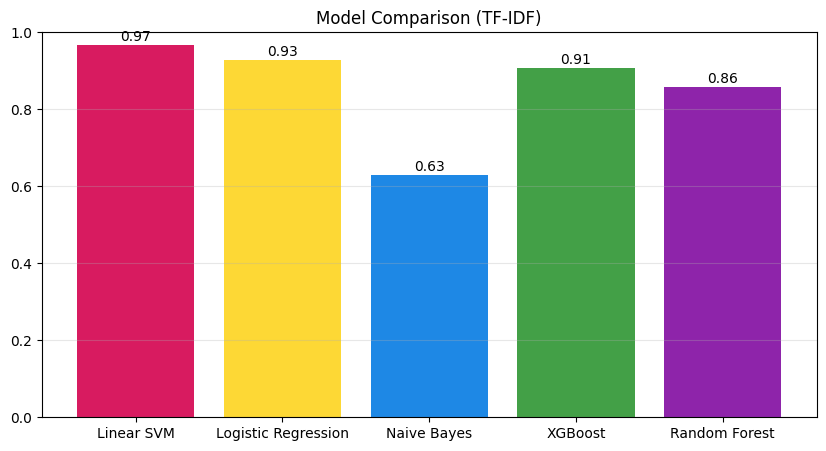

In [45]:
final_results = pd.DataFrame({
    'Model': ['Linear SVM','Logistic Regression','Naive Bayes','XGBoost','Random Forest'],
    'F1-Score': [f1_svm, f1_lr, f1_nb, f1_xgboost, f1_rfc]
})

colors = ['#D81B60', '#FDD835', '#1E88E5', '#43A047', '#8E24AA']

plt.figure(figsize=(10,5))
bars = plt.bar(final_results['Model'], final_results['F1-Score'], color=colors)

plt.ylim(0,1)
plt.title('Model Comparison (TF-IDF)')
plt.grid(axis='y', alpha=0.3)

for b, v in zip(bars, final_results['F1-Score']):
    plt.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}', ha='center')

plt.show()

### **B. Universal Sentence Encoder (USE)**

In [27]:
print('B: UNIVERSAL SENTENCE ENCODER (USE)')

print('Memuat USE dari TensorFlow Hub...')
start = timer()
use_embed = hub.load('https://tfhub.dev/google/universal-sentence-encoder/4')
print(f'USE dimuat dalam {timer()-start:.2f} detik')



B: UNIVERSAL SENTENCE ENCODER (USE)
Memuat USE dari TensorFlow Hub...
USE dimuat dalam 44.66 detik


In [28]:
# Embedding with batching (efficient processing)
print('Embedding training data...')
start = timer()

xtrain_use = np.vstack([
    use_embed(xtrain.tolist()[i:i+batch_size]).numpy()
    for i in range(0, len(xtrain), batch_size)
])

print(f'Train USE : {xtrain_use.shape} | {timer()-start:.2f}s')
print(f'Estimated memory usage: {xtrain_use.nbytes / 1e6:.1f} MB')

print('\nEmbedding testing data...')
start = timer()

xtest_use = np.vstack([
    use_embed(xtest.tolist()[i:i+batch_size]).numpy()
    for i in range(0, len(xtest), batch_size)
])

print(f'Test USE  : {xtest_use.shape} | {timer()-start:.2f}s')

Embedding training data...
Train USE : (16606, 512) | 2.09s
Estimated memory usage: 34.0 MB

Embedding testing data...
Test USE  : (4152, 512) | 0.63s


In [29]:
# Training 4 classifier USE (Without Naive Bayes)
svm_c, lr_c, _, xgb_c, rfc_c = init_classifiers()
print('Training classifier USE...')
print()

start = timer(); svm_use = svm_c.fit(xtrain_use, ytrain)
print(f'  Linear SVM    : {timer()-start:.2f}s')

start = timer(); lr_use = lr_c.fit(xtrain_use, ytrain)
print(f'  Logistic Reg  : {timer()-start:.2f}s')

start = timer(); xgb_use = xgb_c.fit(xtrain_use, ytrain, sample_weight=sample_weights)
print(f'  XGBoost       : {timer()-start:.2f}s')

start = timer(); rfc_use = rfc_c.fit(xtrain_use, ytrain)
print(f'  Random Forest : {timer()-start:.2f}s')
print()
print('Training USE Completed.')

Training classifier USE...

  Linear SVM    : 9.74s
  Logistic Reg  : 4.06s
  XGBoost       : 56.59s
  Random Forest : 31.80s

Training USE Completed.


#### **Linear SVM (USE)**

In [30]:
print('Linear SVM (USE)')
y_pred_svm_use, acc_svm_use, prec_svm_use, rec_svm_use, f1_svm_use, rep_svm_use, cm_svm_use = \
    evaluate_model(svm_use, xtest_use, ytest)

# Example predictions table
svm_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_svm_use[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_svm_use[:15])]
})

display(svm_table)

# Metrics table
svm_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_svm_use, prec_svm_use, rec_svm_use, f1_svm_use]
})

display(svm_metrics)

print('\nClassification Report:')
print(rep_svm_use)
print('Confusion Matrix:')
print(cm_svm_use)

Linear SVM (USE)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,negative,X
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,neutral,X
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.825626
1,Precision,0.833876
2,Recall,0.825626
3,F1-Score,0.829044



Classification Report:
              precision    recall  f1-score   support

    negative       0.53      0.63      0.58       496
     neutral       0.85      0.83      0.84      1359
    positive       0.89      0.86      0.88      2297

    accuracy                           0.83      4152
   macro avg       0.76      0.78      0.76      4152
weighted avg       0.83      0.83      0.83      4152

Confusion Matrix:
[[ 314   74  108]
 [  93 1134  132]
 [ 186  131 1980]]


#### **Logistic Regression (USE)**

In [31]:
print('Logistic Regression (USE)')
y_pred_lr_use, acc_lr_use, prec_lr_use, rec_lr_use, f1_lr_use, rep_lr_use, cm_lr_use = \
    evaluate_model(lr_use, xtest_use, ytest)

lr_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_lr_use[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_lr_use[:15])]
})

display(lr_table)

lr_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_lr_use, prec_lr_use, rec_lr_use, f1_lr_use]
})

display(lr_metrics)

print('\nClassification Report:')
print(rep_lr_use)
print('Confusion Matrix:')
print(cm_lr_use)

Logistic Regression (USE)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,negative,X
5,positive,negative,X
6,negative,negative,OK
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.794798
1,Precision,0.835804
2,Recall,0.794798
3,F1-Score,0.807581



Classification Report:
              precision    recall  f1-score   support

    negative       0.43      0.74      0.55       496
     neutral       0.84      0.83      0.83      1359
    positive       0.92      0.79      0.85      2297

    accuracy                           0.79      4152
   macro avg       0.73      0.79      0.74      4152
weighted avg       0.84      0.79      0.81      4152

Confusion Matrix:
[[ 368   63   65]
 [ 145 1123   91]
 [ 336  152 1809]]


#### **XGBoost (USE)**

In [32]:
print('XGBoost (USE)')
y_pred_xgboost_use, acc_xgboost_use, prec_xgboost_use, rec_xgboost_use, f1_xgboost_use, rep_xgboost_use, cm_xgboost_use = \
    evaluate_model(xgb_use, xtest_use, ytest)

xgb_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_xgboost_use[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_xgboost_use[:15])]
})

display(xgb_table)

xgb_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_xgboost_use, prec_xgboost_use, rec_xgboost_use, f1_xgboost_use]
})

display(xgb_metrics)

print('\nClassification Report:')
print(rep_xgboost_use)
print('Confusion Matrix:')
print(cm_xgboost_use)

XGBoost (USE)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,negative,X
5,positive,positive,OK
6,negative,neutral,X
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.818882
1,Precision,0.826526
2,Recall,0.818882
3,F1-Score,0.821940



Classification Report:
              precision    recall  f1-score   support

    negative       0.53      0.61      0.57       496
     neutral       0.83      0.85      0.84      1359
    positive       0.89      0.85      0.87      2297

    accuracy                           0.82      4152
   macro avg       0.75      0.77      0.76      4152
weighted avg       0.83      0.82      0.82      4152

Confusion Matrix:
[[ 305   80  111]
 [  81 1152  126]
 [ 191  163 1943]]


#### **Random Forest (USE)**

In [33]:
print('Random Forest (USE)')
y_pred_rfc_use, acc_rfc_use, prec_rfc_use, rec_rfc_use, f1_rfc_use, rep_rfc_use, cm_rfc_use = \
    evaluate_model(rfc_use, xtest_use, ytest)

rfc_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_rfc_use[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_rfc_use[:15])]
})

display(rfc_table)

rfc_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_rfc_use, prec_rfc_use, rec_rfc_use, f1_rfc_use]
})

display(rfc_metrics)

print('\nClassification Report:')
print(rep_rfc_use)
print('Confusion Matrix:')
print(cm_rfc_use)

Random Forest (USE)


,Actual,Predicted,Status
0,negative,positive,X
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,positive,X
5,positive,positive,OK
6,negative,neutral,X
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.807563
1,Precision,0.800354
2,Recall,0.807563
3,F1-Score,0.794769



Classification Report:
              precision    recall  f1-score   support

    negative       0.70      0.33      0.45       496
     neutral       0.82      0.81      0.81      1359
    positive       0.81      0.91      0.86      2297

    accuracy                           0.81      4152
   macro avg       0.78      0.68      0.71      4152
weighted avg       0.80      0.81      0.79      4152

Confusion Matrix:
[[ 165   91  240]
 [  16 1100  243]
 [  56  153 2088]]


#### **USE Accuracy Comparison**

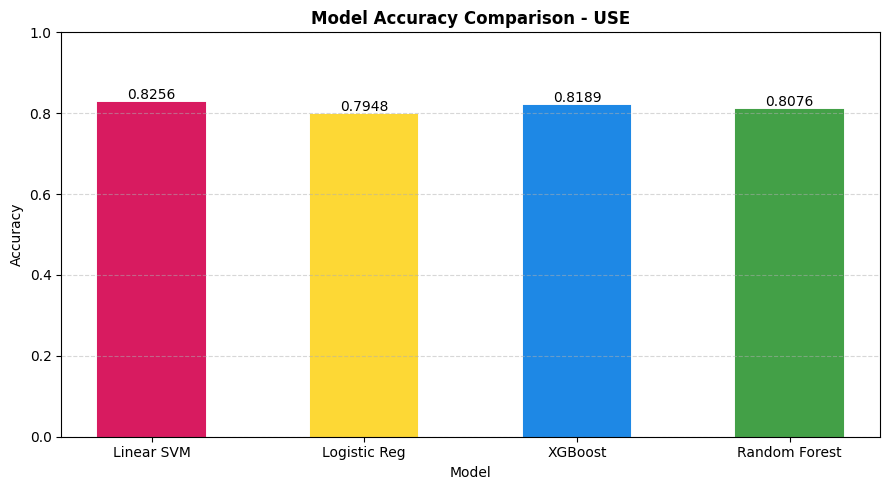

In [34]:
names_use = ['Linear SVM','Logistic Reg','XGBoost','Random Forest']
accs_use  = [acc_svm_use, acc_lr_use, acc_xgboost_use, acc_rfc_use]

colors = ['#D81B60', '#FDD835', '#1E88E5', '#43A047']

plt.figure(figsize=(9, 5))

bars = plt.bar(names_use, accs_use, color=colors, width=0.5)

# edgecolor mengikuti warna masing-masing batang (bukan hitam)
for bar, c in zip(bars, colors):
    bar.set_edgecolor(c)
    bar.set_linewidth(1.5)

plt.title('Model Accuracy Comparison - USE', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, accs_use):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}',
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### **C.  TF-IDF + USE**

In [35]:
print('SECTION 3: TF-IDF + USE (COMBINED FEATURES)')

# Convert sparse TF-IDF matrix to dense format
start = timer()
xtrain_tfidf_dense = xtrain_tfidf.toarray()
xtest_tfidf_dense  = xtest_tfidf.toarray()
print(f'Sparse to dense conversion: {timer()-start:.2f}s')

# Concatenate TF-IDF and USE features
start = timer()
xtrain_combined = np.hstack([xtrain_tfidf_dense, xtrain_use])
xtest_combined  = np.hstack([xtest_tfidf_dense, xtest_use])
print(f'Feature concatenation time: {timer()-start:.2f}s')

print()
print(f'Train shape: {xtrain_combined.shape}')
print(f'Test shape : {xtest_combined.shape}')
print(f'Estimated memory: {xtrain_combined.nbytes / 1e9:.2f} GB')

# Free memory
del xtrain_tfidf_dense, xtest_tfidf_dense
print('Temporary dense matrices released.')

SECTION 3: TF-IDF + USE (COMBINED FEATURES)
Sparse to dense conversion: 0.19s
Feature concatenation time: 0.21s

Train shape: (16606, 4549)
Test shape : (4152, 4549)
Estimated memory: 0.60 GB
Temporary dense matrices released.


In [36]:
svm_c, lr_c, _, xgb_c, rfc_c = init_classifiers()

print('Training classifiers on TF-IDF + USE...')
print()

start = timer(); svm_comb = svm_c.fit(xtrain_combined, ytrain)
print(f'  Linear SVM    : {timer()-start:.2f}s')

start = timer(); lr_comb = lr_c.fit(xtrain_combined, ytrain)
print(f'  Logistic Reg  : {timer()-start:.2f}s')

start = timer(); xgb_comb = xgb_c.fit(xtrain_combined, ytrain, sample_weight=sample_weights)
print(f'  XGBoost       : {timer()-start:.2f}s')

start = timer(); rfc_comb = rfc_c.fit(xtrain_combined, ytrain)
print(f'  Random Forest : {timer()-start:.2f}s')

print()
print('Training completed (TF-IDF + USE).')

Training classifiers on TF-IDF + USE...

  Linear SVM    : 6.96s
  Logistic Reg  : 20.16s
  XGBoost       : 118.01s
  Random Forest : 21.58s

Training completed (TF-IDF + USE).


#### **Linear SVM (TF-IDF + USE)**

In [38]:
print('Linear SVM (TF-IDF + USE)')

y_pred_svm_comb, acc_svm_comb, prec_svm_comb, rec_svm_comb, f1_svm_comb, rep_svm_comb, cm_svm_comb = \
    evaluate_model(svm_comb, xtest_combined, ytest)

svm_comb_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_svm_comb[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_svm_comb[:15])]
})

display(svm_comb_table)

svm_comb_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_svm_comb, prec_svm_comb, rec_svm_comb, f1_svm_comb]
})

display(svm_comb_metrics)

print('\nClassification Report:')
print(rep_svm_comb)

print('Confusion Matrix:')
print(cm_svm_comb)

Linear SVM (TF-IDF + USE)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,neutral,OK
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.967967
1,Precision,0.968220
2,Recall,0.967967
3,F1-Score,0.968071



Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.92      0.90       496
     neutral       0.98      0.98      0.98      1359
    positive       0.98      0.97      0.98      2297

    accuracy                           0.97      4152
   macro avg       0.95      0.96      0.95      4152
weighted avg       0.97      0.97      0.97      4152

Confusion Matrix:
[[ 454   11   31]
 [  14 1330   15]
 [  40   22 2235]]


#### **Logistic Regression (TF-IDF + USE)**

In [39]:
print('Logistic Regression (TF-IDF + USE)')

y_pred_lr_comb, acc_lr_comb, prec_lr_comb, rec_lr_comb, f1_lr_comb, rep_lr_comb, cm_lr_comb = \
    evaluate_model(lr_comb, xtest_combined, ytest)

lr_comb_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_lr_comb[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_lr_comb[:15])]
})

display(lr_comb_table)

lr_comb_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_lr_comb, prec_lr_comb, rec_lr_comb, f1_lr_comb]
})

display(lr_comb_metrics)

print('\nClassification Report:')
print(rep_lr_comb)

print('Confusion Matrix:')
print(cm_lr_comb)

Logistic Regression (TF-IDF + USE)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,neutral,OK
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.929672
1,Precision,0.937229
2,Recall,0.929672
3,F1-Score,0.931543



Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.92      0.82       496
     neutral       0.93      0.96      0.95      1359
    positive       0.98      0.91      0.95      2297

    accuracy                           0.93      4152
   macro avg       0.89      0.93      0.90      4152
weighted avg       0.94      0.93      0.93      4152

Confusion Matrix:
[[ 457   23   16]
 [  35 1302   22]
 [ 126   70 2101]]


#### **XGBoost (TF-IDF + USE)**

In [40]:
print('XGBoost (TF-IDF + USE)')

y_pred_xgb_comb, acc_xgb_comb, prec_xgb_comb, rec_xgb_comb, f1_xgb_comb, rep_xgb_comb, cm_xgb_comb = \
    evaluate_model(xgb_comb, xtest_combined, ytest)

xgb_comb_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_xgb_comb[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_xgb_comb[:15])]
})

display(xgb_comb_table)

xgb_comb_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_xgb_comb, prec_xgb_comb, rec_xgb_comb, f1_xgb_comb]
})

display(xgb_comb_metrics)

print('\nClassification Report:')
print(rep_xgb_comb)

print('Confusion Matrix:')
print(cm_xgb_comb)

XGBoost (TF-IDF + USE)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,neutral,OK
5,positive,positive,OK
6,negative,negative,OK
7,positive,positive,OK
8,positive,negative,X
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.895713
1,Precision,0.904147
2,Recall,0.895713
3,F1-Score,0.898074



Classification Report:
              precision    recall  f1-score   support

    negative       0.68      0.80      0.73       496
     neutral       0.87      0.94      0.91      1359
    positive       0.97      0.89      0.93      2297

    accuracy                           0.90      4152
   macro avg       0.84      0.88      0.86      4152
weighted avg       0.90      0.90      0.90      4152

Confusion Matrix:
[[ 395   63   38]
 [  60 1275   24]
 [ 128  120 2049]]


#### **Random Forest (TF-IDF + USE)**

In [41]:
print('Random Forest (TF-IDF + USE)')

y_pred_rfc_comb, acc_rfc_comb, prec_rfc_comb, rec_rfc_comb, f1_rfc_comb, rep_rfc_comb, cm_rfc_comb = \
    evaluate_model(rfc_comb, xtest_combined, ytest)

rfc_comb_table = pd.DataFrame({
    'Actual': [CLASS_NAMES[a] for a in ytest[:15]],
    'Predicted': [CLASS_NAMES[p] for p in y_pred_rfc_comb[:15]],
    'Status': ['OK' if a == p else 'X' for a, p in zip(ytest[:15], y_pred_rfc_comb[:15])]
})

display(rfc_comb_table)

rfc_comb_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc_rfc_comb, prec_rfc_comb, rec_rfc_comb, f1_rfc_comb]
})

display(rfc_comb_metrics)

print('\nClassification Report:')
print(rep_rfc_comb)

print('Confusion Matrix:')
print(cm_rfc_comb)

Random Forest (TF-IDF + USE)


,Actual,Predicted,Status
0,negative,negative,OK
1,positive,positive,OK
2,positive,positive,OK
3,positive,positive,OK
4,neutral,positive,X
5,positive,positive,OK
6,negative,neutral,X
7,positive,positive,OK
8,positive,positive,OK
9,positive,positive,OK


,Metric,Score
0,Accuracy,0.816956
1,Precision,0.812893
2,Recall,0.816956
3,F1-Score,0.804309



Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.35      0.48       496
     neutral       0.82      0.81      0.82      1359
    positive       0.82      0.92      0.87      2297

    accuracy                           0.82      4152
   macro avg       0.80      0.69      0.72      4152
weighted avg       0.81      0.82      0.80      4152

Confusion Matrix:
[[ 173  100  223]
 [  18 1105  236]
 [  37  146 2114]]


#### **TF-IDF & USE Accuracy Comparison**

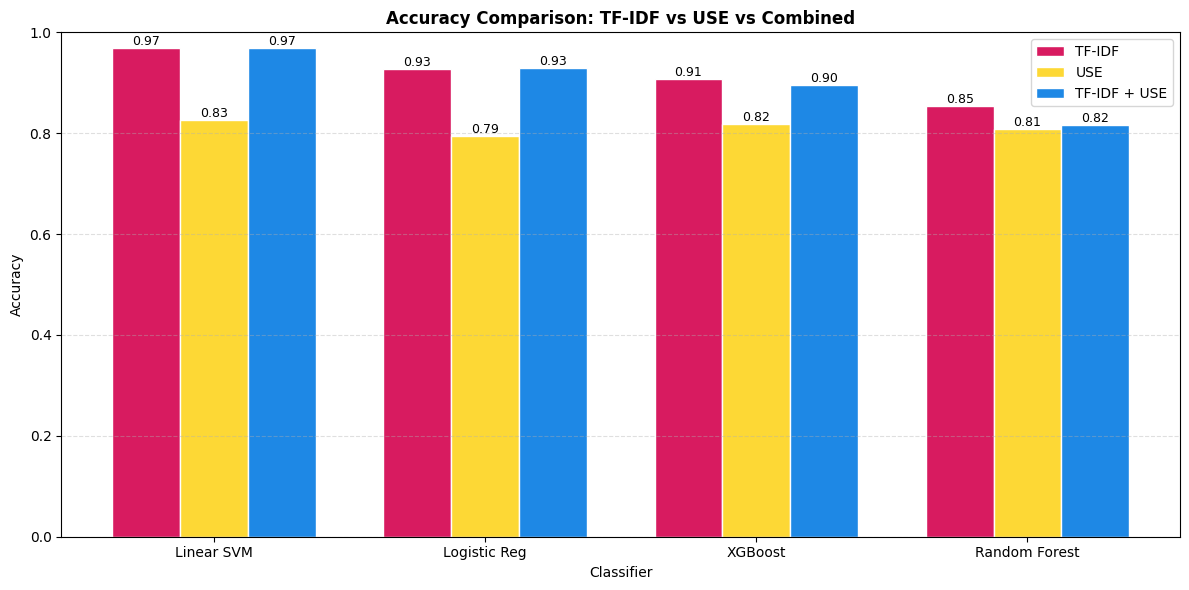

In [43]:
models = ['Linear SVM', 'Logistic Reg', 'XGBoost', 'Random Forest']

scores = {
    'TF-IDF': [acc_svm, acc_lr, acc_xgboost, acc_rfc],
    'USE': [acc_svm_use, acc_lr_use, acc_xgboost_use, acc_rfc_use],
    'TF-IDF + USE': [acc_svm_comb, acc_lr_comb, acc_xgb_comb, acc_rfc_comb]
}

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#D81B60', '#FDD835', '#1E88E5']

for i, (label, vals) in enumerate(scores.items()):
    bars = ax.bar(x + (i-1)*width, vals, width, label=label,
                  color=colors[i], edgecolor='white')

    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.006,
                f'{b.get_height():.2f}', ha='center', fontsize=9)

ax.set_title('Accuracy Comparison: TF-IDF vs USE vs Combined', fontweight='bold')
ax.set_xlabel('Classifier')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

### **Overall Model Performance**

In [44]:
summary_df = pd.DataFrame({
    'Embedding': (
        ['TF-IDF']*5 + ['USE']*4 + ['TF-IDF+USE']*4
    ),
    'Classifier': (
        ['Linear SVM','Logistic Reg','Naive Bayes','XGBoost','Random Forest'] +
        ['Linear SVM','Logistic Reg','XGBoost','Random Forest'] +
        ['Linear SVM','Logistic Reg','XGBoost','Random Forest']
    ),
    'Accuracy': (
        [acc_svm, acc_lr, acc_nb, acc_xgboost, acc_rfc] +
        [acc_svm_use, acc_lr_use, acc_xgboost_use, acc_rfc_use] +
        [acc_svm_comb, acc_lr_comb, acc_xgb_comb, acc_rfc_comb]
    ),
    'F1': (
        [f1_svm, f1_lr, f1_nb, f1_xgboost, f1_rfc] +
        [f1_svm_use, f1_lr_use, f1_xgboost_use, f1_rfc_use] +
        [f1_svm_comb, f1_lr_comb, f1_xgb_comb, f1_rfc_comb]
    )
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

summary_df[['Accuracy','F1']] = summary_df[['Accuracy','F1']].round(4)

display(summary_df)

best = summary_df.iloc[0]
print(f'Best: {best.Classifier} ({best.Embedding}) | Acc={best.Accuracy:.4f} | F1={best.F1:.4f}')

,Embedding,Classifier,Accuracy,F1
0,TF-IDF,Linear SVM,0.9682,0.9682
1,TF-IDF+USE,Linear SVM,0.9680,0.9681
2,TF-IDF+USE,Logistic Reg,0.9297,0.9315
3,TF-IDF,Logistic Reg,0.9275,0.9285
4,TF-IDF,XGBoost,0.9068,0.9074
5,TF-IDF+USE,XGBoost,0.8957,0.8981
6,TF-IDF,Random Forest,0.8545,0.8577
7,USE,Linear SVM,0.8256,0.8290
8,USE,XGBoost,0.8189,0.8219
9,TF-IDF+USE,Random Forest,0.8170,0.8043


Best: Linear SVM (TF-IDF) | Acc=0.9682 | F1=0.9682


### **Summary**

Best Overall Model:
- Linear SVM (TF-IDF)
- Accuracy : 0.9682
- F1-Score : 0.9682

Key Insights:
- TF-IDF consistently outperforms USE and TF-IDF+USE for most classifiers.
- Adding USE embedding does not significantly improve Linear SVM performance.
- Logistic Regression is stable and strong (~0.93 F1) across embeddings.
- XGBoost performs well (~0.90 F1) but slightly decreases with hybrid features.
- Random Forest performs lower compared to linear models.
- Naive Bayes has the lowest performance among all models.

Overall Conclusion:
TF-IDF combined with Linear SVM provides the best and most stable performance
for this sentiment classification task.